In [39]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import OrdinalEncoder

In [40]:
df = pd.read_csv("/content/insurance_pre.csv")

In [41]:
df

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [42]:
df["charges_bin"] = pd.qcut(df["charges"], q=3, labels=["Low", "Medium", "High"])
y = df["charges_bin"]
X = df.drop(["charges", "charges_bin"], axis=1)


In [43]:
# Encode ALL feature columns
enc = OrdinalEncoder()
X_encoded = enc.fit_transform(X)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.25, random_state=42)


In [45]:
# Train CategoricalNB
cnb = CategoricalNB()
cnb.fit(X_train, y_train)

# Predictions
y_pred = cnb.predict(X_test)

In [48]:
print("=== CategoricalNB Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred))

=== CategoricalNB Results ===
Accuracy: 0.8686567164179104


Classification Report:

              precision    recall  f1-score   support

        High       0.93      0.77      0.84       112
         Low       0.88      0.91      0.89       118
      Medium       0.81      0.93      0.87       105

    accuracy                           0.87       335
   macro avg       0.87      0.87      0.87       335
weighted avg       0.88      0.87      0.87       335



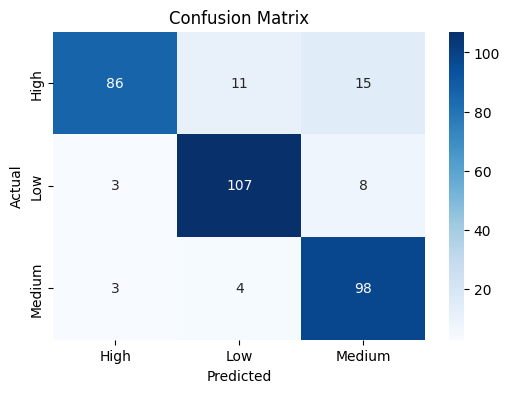

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

report = classification_report(y_test, y_pred)
print("Classification Report:\n")
print(report)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cnb.classes_, yticklabels=cnb.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [47]:
# Save model using pickle
with open("categorical_nb.pkl", "wb") as f:
    pickle.dump(cnb, f)

print("\nModel saved as categorical_nb.pkl")

# Load model back
with open("categorical_nb.pkl", "rb") as f:
    loaded_model = pickle.load(f)

# Test loaded model
y_pred_loaded = loaded_model.predict(X_test[:5])
print("\nLoaded model predicts:", y_pred_loaded)
print("Actual:", list(y_test[:5]))


Model saved as categorical_nb.pkl

Loaded model predicts: ['Medium' 'Low' 'High' 'Medium' 'High']
Actual: ['Medium', 'Low', 'High', 'Medium', 'High']
